# Consensus pseudo-labelling

Runs the configured pretrained pickers on QC-valid windows, applies phase-wise consensus and quality checks, and stores labels for dataset construction.


In [1]:
# ==========================================
# 1. IMPORTS AND PATHS
# ==========================================
import os
import sys

# Jupyter kernels start WITHOUT running conda activation, so the environment's
# DLL directories are off PATH and torch fails to load fbgemm.dll (WinError 127).
# Prepend them here to mimic activation. Also allow the duplicate OpenMP runtime
# (torch's libomp vs MKL's libiomp5md) and import torch BEFORE obspy/seisbench.
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")
for _dll_dir in (os.path.join(sys.prefix, "Library", "bin"),
                 os.path.join(sys.prefix, "Library", "mingw-w64", "bin"),
                 sys.prefix):
    if os.path.isdir(_dll_dir):
        os.environ["PATH"] = _dll_dir + os.pathsep + os.environ.get("PATH", "")

import torch  # noqa: E402  (import before obspy/seisbench on Windows)

import logging
logging.getLogger("seisbench").setLevel(logging.ERROR)  # hide per-window EQCCT warnings

from pathlib import Path

import numpy as np
import pandas as pd


def _find_repo_root(start: Path) -> Path:
    for p in (start, *start.parents):
        if (p / "data" / "raw").is_dir() and (p / "src").is_dir():
            return p
    return start


REPO_ROOT = _find_repo_root(Path.cwd().resolve())
sys.path.insert(0, str(REPO_ROOT / "src" / "preprocessing"))
sys.path.insert(0, str(REPO_ROOT / "src" / "labeling"))

import importlib
import preprocessing_utils as pp        # noqa: E402  (single source of conditioning)
import consensus_utils as cu            # noqa: E402  (consensus core)
importlib.reload(pp)                    # pick up edits to the .py without a full restart
importlib.reload(cu)                    # (remember to re-run cell 3 so models use the new code)

WAVEFORMS_DIR = REPO_ROOT / "data" / "raw" / "waveforms"
INVENTORY_DIR = REPO_ROOT / "data" / "interim" / "preprocessing"
# Labelling-stage outputs: kept labels (earthquake + noise) and the unlabelled
# windows set aside for later manual review / statistics.
LABELING_DIR = REPO_ROOT / "data" / "processed" / "labeling"
UNLABELING_DIR = REPO_ROOT / "data" / "processed" / "unlabeling"
LABELING_DIR.mkdir(parents=True, exist_ok=True)
UNLABELING_DIR.mkdir(parents=True, exist_ok=True)

print(f"Repo root:   {REPO_ROOT}")
print(f"Waveforms:   {WAVEFORMS_DIR}")
print(f"Inventories: {INVENTORY_DIR}")
print(f"Labels ->    {LABELING_DIR}")
print(f"Unlabelled ->{UNLABELING_DIR}")

Repo root:   M:\Github\TFM_SeismicPhasePicker_ColombianAndes
Waveforms:   M:\Github\TFM_SeismicPhasePicker_ColombianAndes\data\raw\waveforms
Inventories: M:\Github\TFM_SeismicPhasePicker_ColombianAndes\data\interim\preprocessing
Labels ->    M:\Github\TFM_SeismicPhasePicker_ColombianAndes\data\processed\labeling
Unlabelled ->M:\Github\TFM_SeismicPhasePicker_ColombianAndes\data\processed\unlabeling


In [2]:
# ==========================================
# 2. CONFIGURATION
# ==========================================
# Pretrained weights for the four consensus architectures. EQCCT's separate
# P and S pickers count as one architecture in each phase.
MODEL_WEIGHTS = {
    "PhaseNet": "instance",
    "EQTransformer": "instance",
    "EQCCT_P": "original",
    "EQCCT_S": "original",
    "GPD": "instance",
}

# Independent P and S voting uses phase-specific thresholds and tolerances.
MIN_P, THR_P, TOL_P = 3, 0.30, 20     # P: 3 of 4 models, prob >= 0.30, within 0.2 s
MIN_S, THR_S, TOL_S = 2, 0.15, 30     # S: 2 of 4 models, prob >= 0.15, within 0.3 s
NOISE_MAX_PROB = 0.15                 # noise only if retained picks stay below this

# Remove low-SNR picks individually; retain an event if a phase survives.
SNR_CUT = 0.0                         # dB floor for each accepted phase
APPLY_SNR_QC = True

# --- TEST controls (used by cell 4) ---
TEST_STATION = "ZAR"                  # station for the sample run
TEST_MAX_WINDOWS = 30

# --- FULL-RUN controls (used by cell 7) ---
EXCLUDED = {"PTB1", "RIO2C", "YPLC"}
ALL_STATIONS = sorted(
    d.name for d in WAVEFORMS_DIR.iterdir()
    if d.is_dir() and d.name not in EXCLUDED
)

# Process unfinished stations; existing rows also permit window-level resumption.
_done = {f.stem.replace("labels_", "") for f in LABELING_DIR.glob("labels_*.csv")}
PENDING = [s for s in ALL_STATIONS if s not in _done]

STATIONS_TO_PROCESS = PENDING             # remaining (auto-detected) stations
# STATIONS_TO_PROCESS = ["ZAR"]           # single station (smoke test)
# STATIONS_TO_PROCESS = ALL_STATIONS      # all 22 (skips finished ones window-by-window)

print(f"Available ({len(ALL_STATIONS)}): {', '.join(ALL_STATIONS)}")
print(f"Already done ({len(_done)}): {', '.join(sorted(_done)) if _done else '(none)'}")
print(f"This run will process ({len(STATIONS_TO_PROCESS)}): {STATIONS_TO_PROCESS}")

Available (22): BRJC, CBOC, CHI, DBB, GUY2C, JAMC, MAL, NOR, ORTC, PAL, PIZC, PRA, PTB, PTGC, QUBC, RUS, SPBC, TAM, URE, URMC, YOT, ZAR
Already done (13): BRJC, CBOC, CHI, DBB, GUY2C, JAMC, MAL, NOR, ORTC, PAL, PIZC, PRA, PTB
This run will process (9): ['PTGC', 'QUBC', 'RUS', 'SPBC', 'TAM', 'URE', 'URMC', 'YOT', 'ZAR']


In [3]:
# ==========================================
# 3. LOAD THE FOUR MODELS  (+ labelling helpers)
# ==========================================
# Load the configured SeisBench weights and report unavailable names.
import torch

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}"
      + (f" ({torch.cuda.get_device_name(0)})" if DEVICE == "cuda" else " (CPU: ok for TEST, slow for full run)"))

models = cu.load_models(MODEL_WEIGHTS, device=DEVICE)
print(f"\nConsensus models ({len(models)}): {list(models)}")


def label(arr, trace_name, timestamp, station):
    """Decoupled per-phase consensus + SNR QC with this notebook's config."""
    return cu.label_window_decoupled(
        arr, trace_name, station, timestamp, models,
        min_p=MIN_P, thr_p=THR_P, tol_p=TOL_P,
        min_s=MIN_S, thr_s=THR_S, tol_s=TOL_S,
        noise_max_prob=NOISE_MAX_PROB, snr_cut_db=SNR_CUT, apply_snr_qc=APPLY_SNR_QC,
    )


def label_row(lab):
    """Flatten a WindowLabel into a CSV row (samples + seconds + provenance)."""
    fs = cu.SAMPLING_RATE_HZ
    return {
        "trace_name": lab.trace_name,
        "station_code": lab.station_code,
        "timestamp": lab.timestamp,
        "category": lab.category,
        "p_sample": lab.p_sample,
        "s_sample": lab.s_sample,
        "p_time_s": round(lab.p_sample / fs, 3) if lab.p_sample is not None else None,
        "s_time_s": round(lab.s_sample / fs, 3) if lab.s_sample is not None else None,
        "p_n_models": lab.p_n_models,
        "s_n_models": lab.s_n_models,
        "p_prob": round(lab.p_prob, 4),
        "s_prob": round(lab.s_prob, 4),
        "snr_p_db": round(lab.snr_p, 2) if lab.snr_p == lab.snr_p else None,
        "snr_s_db": round(lab.snr_s, 2) if lab.snr_s == lab.snr_s else None,
    }


# Combine SAC event headers, catalog attributes, and station coordinates.
# Catalog matches use rounded event coordinates; unmatched fields stay empty.
from obspy.geodetics import gps2dist_azimuth

CATALOG_DIR = REPO_ROOT / "data" / "raw" / "catalog"
_events = pd.read_csv(CATALOG_DIR / "Events_2018_2025.csv")
_EVT = {(round(float(r["LATITUD (\u00b0)"]), 3), round(float(r["LONGITUD (\u00b0)"]), 3)):
        (float(r["MAGNITUD"]), float(r["PROF. (Km)"]))
        for _, r in _events.iterrows()}
_STA = pd.read_csv(CATALOG_DIR / "Stations_Required.csv").set_index("Code")
print(f"Catalog loaded: {len(_EVT)} event epicentres, {len(_STA)} stations")


def source_station_meta(station_dir, timestamp, station):
    """Event + station geometry for one window (SAC header + catalog lookups)."""
    m = {"source_latitude": None, "source_longitude": None, "source_depth_km": None,
         "source_magnitude": None, "station_latitude": None, "station_longitude": None,
         "station_elevation_m": None, "distance_km": None, "back_azimuth": None}
    hdr = pp.read_window_sac_header(station_dir, timestamp, station)
    if hdr is None:
        return m
    evla, evlo = hdr["evla"], hdr["evlo"]
    m["source_latitude"], m["source_longitude"], m["source_depth_km"] = evla, evlo, hdr["evdp"]
    m["back_azimuth"] = round(hdr["baz"], 2) if hdr["baz"] is not None else None
    if evla is not None and evlo is not None:
        hit = _EVT.get((round(evla, 3), round(evlo, 3)))
        if hit is not None:
            m["source_magnitude"], m["source_depth_km"] = hit          # catalog depth
    if station in _STA.index:
        s = _STA.loc[station]
        stla, stlo, stel = float(s["Latitude"]), float(s["Longitude"]), float(s["Elevation"])
        m["station_latitude"], m["station_longitude"], m["station_elevation_m"] = stla, stlo, stel
        if evla is not None and evlo is not None:
            dist_m, _az, baz = gps2dist_azimuth(evla, evlo, stla, stlo)
            m["distance_km"], m["back_azimuth"] = round(dist_m / 1000.0, 2), round(baz, 2)
    return m

Device: cuda (NVIDIA GeForce RTX 3050 Laptop GPU)


c:\Users\moise\miniconda3\envs\tesismaster\Lib\site-packages\seisbench\models\base.py:952: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_weights = torch.load(f"{path_p

[ok] PhaseNet <- 'instance' on cuda
[ok] EQTransformer <- 'instance' on cuda
[ok] GPD <- 'instance' on cuda
[ok] EQCCT <- EQCCTP+EQCCTS ('original') on cuda

Consensus models (4): ['PhaseNet', 'EQTransformer', 'GPD', 'EQCCT']
Catalog loaded: 105274 event epicentres, 25 stations


ZAR: 30 windows ->
unlabelled    19
earthquake     8
noise          3


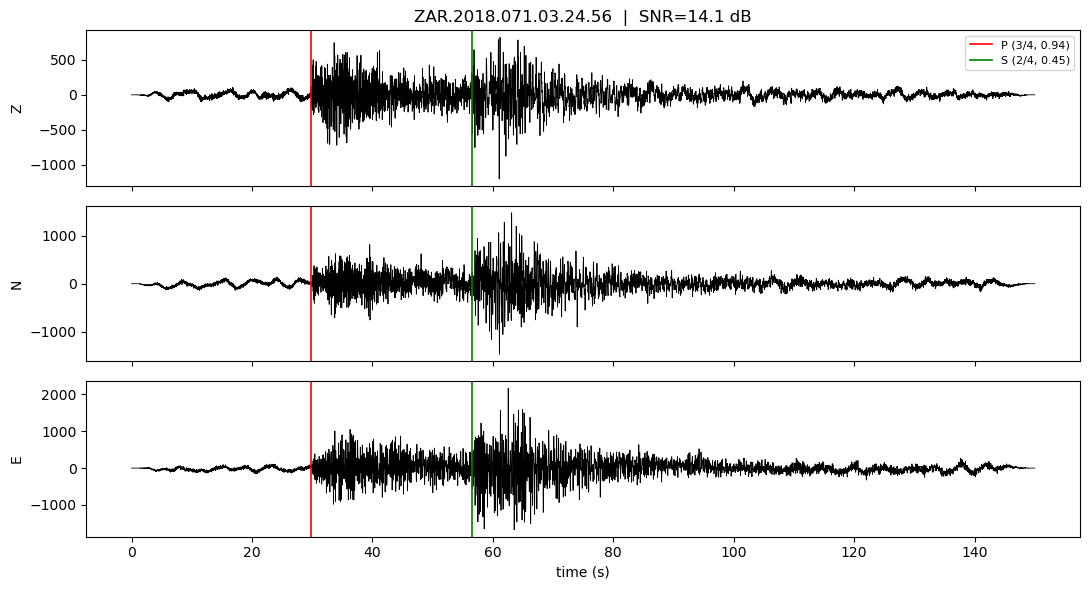


Raw per-model picks (model, phase, sample, prob):
  PhaseNet       P  sample=  2979  prob=0.94
  PhaseNet       S  sample=  5653  prob=0.19
  EQTransformer  P  sample=  2976  prob=0.89
  GPD            P  sample=   430  prob=0.39
  GPD            P  sample=  2980  prob=0.98
  GPD            S  sample=  3240  prob=0.61
  GPD            S  sample=  5660  prob=0.72
  GPD            S  sample=  5980  prob=0.16


In [4]:
# ==========================================
# 4. TEST RUN  (one station, few windows)  ->  RUN THIS FIRST
# ==========================================
# Inspect the picks and the consensus on a handful of windows before the full
# run. Plots the first window that gets a consensus P with the picks overlaid.
import matplotlib.pyplot as plt

inv = pd.read_csv(INVENTORY_DIR / f"window_inventory_{TEST_STATION}.csv")
valid = inv[inv["status"] == "ok"].head(TEST_MAX_WINDOWS)
station_dir = WAVEFORMS_DIR / TEST_STATION

labels = []
for _, row in valid.iterrows():
    arr = pp.load_window_array(station_dir, row["timestamp"], TEST_STATION, preprocess=True)
    if arr is None:
        continue
    lab = label(arr, row["trace_name"], row["timestamp"], TEST_STATION)
    labels.append((lab, arr))

cats = pd.Series([l.category for l, _ in labels]).value_counts()
print(f"{TEST_STATION}: {len(labels)} windows ->")
print(cats.to_string())

# Plot the first earthquake window with its consensus picks.
eq = next((pair for pair in labels if pair[0].category == "earthquake"), None)
if eq is None:
    print("\nNo consensus P in this sample; try more windows or lower THRESHOLDS.")
else:
    lab, arr = eq
    t = np.arange(arr.shape[1]) / cu.SAMPLING_RATE_HZ
    fig, ax = plt.subplots(3, 1, figsize=(11, 6), sharex=True)
    for i, comp in enumerate("ZNE"):
        ax[i].plot(t, arr[i], lw=0.6, color="k")
        ax[i].set_ylabel(comp)
        if lab.p_sample is not None:
            ax[i].axvline(lab.p_sample / cu.SAMPLING_RATE_HZ, color="r", lw=1.2,
                          label=f"P ({lab.p_n_models}/{len(models)}, {lab.p_prob:.2f})")
        if lab.s_sample is not None:
            ax[i].axvline(lab.s_sample / cu.SAMPLING_RATE_HZ, color="g", lw=1.2,
                          label=f"S ({lab.s_n_models}/{len(models)}, {lab.s_prob:.2f})")
    ax[0].legend(loc="upper right", fontsize=8)
    ax[0].set_title(f"{lab.trace_name}  |  SNR={lab.snr_db:.1f} dB")
    ax[-1].set_xlabel("time (s)")
    plt.tight_layout()
    plt.show()
    print("\nRaw per-model picks (model, phase, sample, prob):")
    for p in lab.all_picks:
        print(f"  {p.model:<14} {p.phase}  sample={p.sample:>6}  prob={p.prob:.2f}")

ZAR: 60 window(s) with category='any' (scanned 60)

 idx         timestamp   category  PN_P  EQT_P  GPD_P  CCT_P  PN_S  EQT_S  GPD_S  CCT_S  P_smp   P_s  S_smp   S_s  Pn  Sn  SNR
   0 2018.070.13.30.38 unlabelled  0.74   0.11   0.80   0.19  0.17   0.10   0.70   0.39    NaN   NaN    NaN   NaN   0   0  NaN
   1 2018.070.13.31.09 unlabelled  0.09   0.00   0.29   0.00  0.17   0.09   0.71   0.42    NaN   NaN    NaN   NaN   0   0  NaN
   2 2018.070.21.34.17 unlabelled  0.00   0.00   0.17   0.00  0.00   0.00   0.21   0.00    NaN   NaN    NaN   NaN   0   0  NaN
   3 2018.071.03.24.56 earthquake  0.94   0.89   0.98   0.00  0.19   0.07   0.72   0.12 2978.0 29.78 5659.0 56.59   3   2 14.1
   4 2018.071.10.20.28 unlabelled  0.39   0.28   0.78   0.28  0.15   0.20   0.68   0.34    NaN   NaN    NaN   NaN   0   0  NaN
   5 2018.071.10.51.21 earthquake  0.72   0.66   0.82   0.19  0.15   0.08   0.61   0.39 2831.0 28.31 4939.0 49.39   3   2  1.4
   6 2018.072.06.35.07 earthquake  0.91   0.88   0.78   0.6

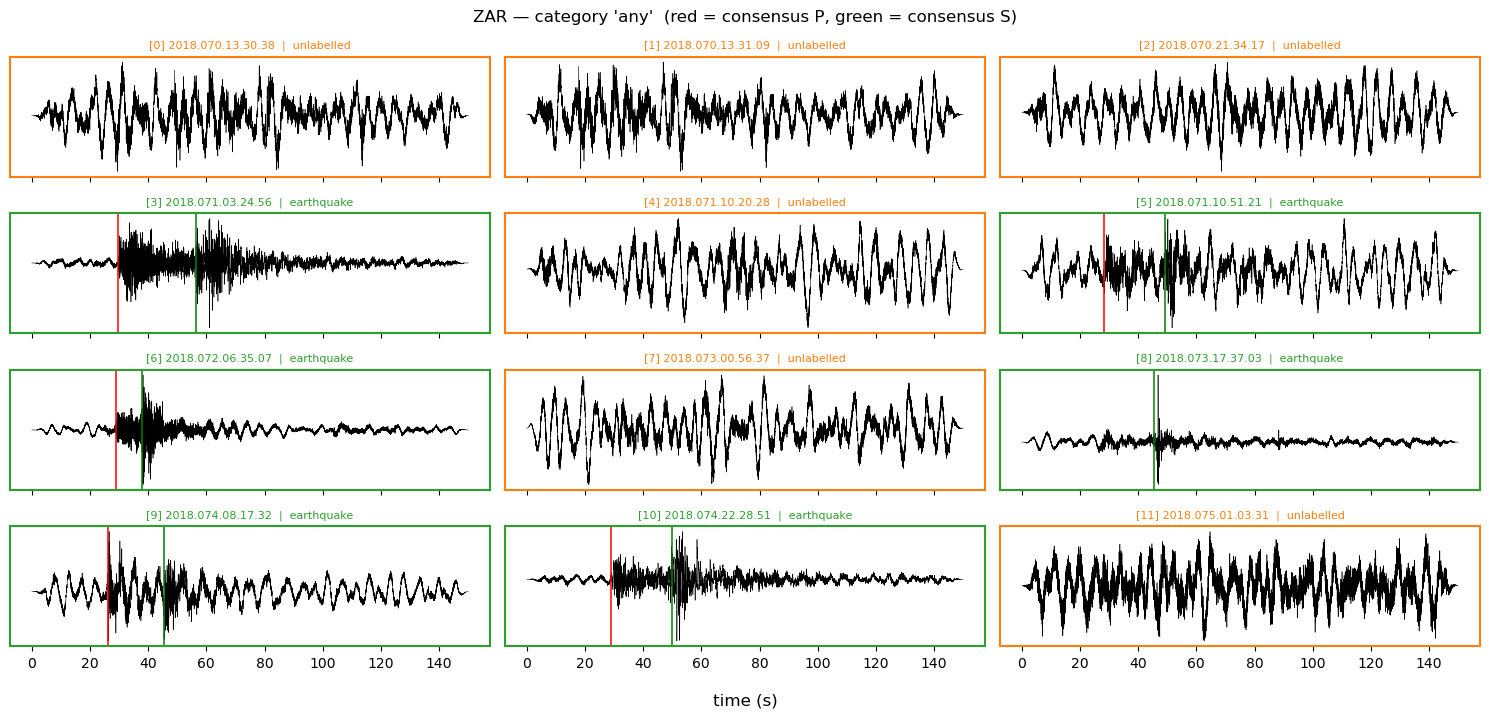

In [5]:
# ==========================================
# 4b. DIAGNOSTIC: inspect windows of ANY category with per-model scores
# ==========================================
# Inspect phase-wise consensus without a theoretical arrival anchor.
# Scan the selected station/category and display:
#   * each model's maximum P/S scores and the accepted consensus picks;
#   * Z-component traces with accepted P/S markers.
import matplotlib.pyplot as plt

DIAG_STATION  = TEST_STATION       # any station code that has an inventory CSV
DIAG_CATEGORY = "any"              # "any" | "earthquake" | "unlabelled" | "noise"
DIAG_SCAN     = 60                 # how many valid windows to scan
DIAG_MAX_PLOT = 12                 # how many matching windows to plot

_MODEL_ORDER = list(models.keys())
_SHORT = {"PhaseNet": "PN", "EQTransformer": "EQT", "EQCCT": "CCT", "GPD": "GPD"}


def _per_model_probs(arr, floor=0.05):
    """Max peak probability each model assigns to P and to S.

    Uses a low internal detection threshold (``floor``) so weak picks below the
    consensus vote threshold are still visible here (EQCCT defaults to 0.5).
    """
    st = cu.array_to_stream(arr, station=DIAG_STATION[:4])
    scores = {m: {"P": 0.0, "S": 0.0} for m in _MODEL_ORDER}
    for name, model in models.items():
        for pk in model.classify(st, P_threshold=floor, S_threshold=floor).picks:
            ph = str(pk.phase).upper()
            if ph in ("P", "S"):
                scores[name][ph] = max(scores[name][ph], float(pk.peak_value))
    return scores


inv = pd.read_csv(INVENTORY_DIR / f"window_inventory_{DIAG_STATION}.csv")
valid = inv[inv["status"] == "ok"].head(DIAG_SCAN)
station_dir = WAVEFORMS_DIR / DIAG_STATION
fs = cu.SAMPLING_RATE_HZ

records = []                       # (idx, timestamp, arr, lab, per_model_scores)
# Use the reported index as INSPECT_INDEX in the next cell.
for idx, (_, row) in enumerate(valid.iterrows()):
    arr = pp.load_window_array(station_dir, row["timestamp"], DIAG_STATION, preprocess=True)
    if arr is None:
        continue
    lab = label(arr, row["trace_name"], row["timestamp"], DIAG_STATION)
    if DIAG_CATEGORY != "any" and lab.category != DIAG_CATEGORY:
        continue
    records.append((idx, row["timestamp"], arr, lab, _per_model_probs(arr)))

print(f"{DIAG_STATION}: {len(records)} window(s) with category='{DIAG_CATEGORY}' "
      f"(scanned {len(valid)})\n")

# ---- table: per-model P/S scores + consensus picks ----
diag_rows = []
for idx, ts, arr, lab, sc in records:
    entry = {"idx": idx, "timestamp": ts, "category": lab.category}
    for m in _MODEL_ORDER:                       # one P column per model...
        entry[f"{_SHORT.get(m, m)}_P"] = round(sc[m]["P"], 2)
    for m in _MODEL_ORDER:                       # ...then one S column per model
        entry[f"{_SHORT.get(m, m)}_S"] = round(sc[m]["S"], 2)
    entry.update({
        "P_smp": lab.p_sample,
        "P_s": None if lab.p_sample is None else round(lab.p_sample / fs, 2),
        "S_smp": lab.s_sample,
        "S_s": None if lab.s_sample is None else round(lab.s_sample / fs, 2),
        "Pn": lab.p_n_models,
        "Sn": lab.s_n_models,
        "SNR": None if lab.snr_db != lab.snr_db else round(lab.snr_db, 1),
    })
    diag_rows.append(entry)
diag_df = pd.DataFrame(diag_rows)
if not diag_df.empty:
    with pd.option_context("display.max_rows", None, "display.width", 220):
        print(diag_df.to_string(index=False))

# ---- grid plot of the matching windows ----
CAT_COLOR = {"earthquake": "#2ca02c", "unlabelled": "#ff7f0e", "noise": "#7f7f7f"}
plot_recs = records[:DIAG_MAX_PLOT]
if plot_recs:
    t = np.arange(pp.NPTS) / fs
    ncol = 3
    nrow = int(np.ceil(len(plot_recs) / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(5 * ncol, 1.8 * nrow), sharex=True)
    axes = np.atleast_1d(axes).ravel()
    for i, (idx, ts, arr, lab, sc) in enumerate(plot_recs):
        ax = axes[i]
        ax.plot(t, arr[0], lw=0.4, color="k")          # Z component
        if lab.p_sample is not None:
            ax.axvline(lab.p_sample / fs, color="r", lw=1.1)
        if lab.s_sample is not None:
            ax.axvline(lab.s_sample / fs, color="g", lw=1.1)
        ax.set_title(f"[{idx}] {ts}  |  {lab.category}", fontsize=8,
                     color=CAT_COLOR.get(lab.category, "k"))
        ax.set_yticks([])
        for sp in ax.spines.values():
            sp.set_edgecolor(CAT_COLOR.get(lab.category, "k"))
            sp.set_linewidth(1.5)
    for j in range(len(plot_recs), len(axes)):
        axes[j].axis("off")
    fig.supxlabel("time (s)")
    fig.suptitle(f"{DIAG_STATION} — category '{DIAG_CATEGORY}'  "
                 f"(red = consensus P, green = consensus S)")
    fig.tight_layout()
    plt.show()
else:
    print("No windows to plot for this category.")

ZAR  |  window index 4  |  2018.071.10.20.28  |  category=unlabelled  (2034 valid windows total)

Per-model max probability (floor 0.05):
               P_prob  S_prob
PhaseNet         0.39    0.15
EQTransformer    0.28    0.20
GPD              0.78    0.68
EQCCT            0.28    0.34

Consensus P: -
Consensus S: -
SNR: -


C:\Users\moise\AppData\Local\Temp\ipykernel_21500\2593204112.py:85: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[0].legend(loc="upper right", fontsize=8)


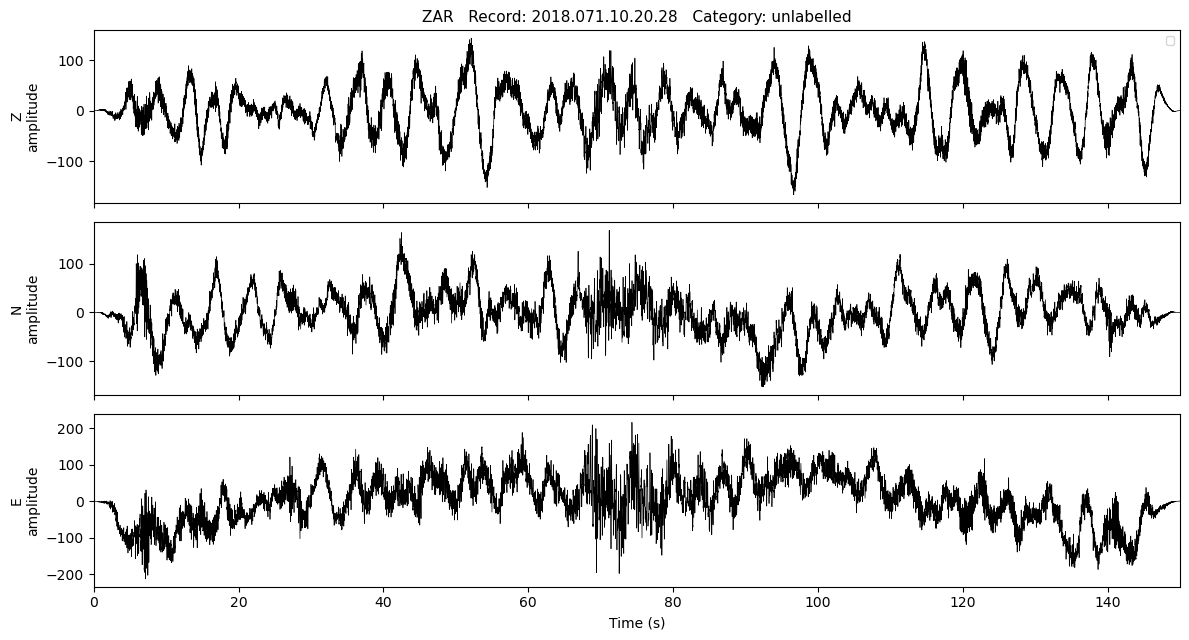

In [6]:
# ==========================================
# 4c. INSPECT ONE WINDOW (3 components) — step through records one by one
# ==========================================
# Step through valid windows by INSPECT_INDEX.
# Display Z/N/E, accepted P/S markers, and model scores.
import matplotlib.pyplot as plt

INSPECT_STATION  = TEST_STATION    # any station code that has an inventory CSV
INSPECT_INDEX    = 4              # 0-based; increase to move to the next record
INSPECT_CATEGORY = "any"           # "any" | "earthquake" | "unlabelled" | "noise"

_inv = pd.read_csv(INVENTORY_DIR / f"window_inventory_{INSPECT_STATION}.csv")
_valid = _inv[_inv["status"] == "ok"].reset_index(drop=True)
station_dir_ins = WAVEFORMS_DIR / INSPECT_STATION
fs = cu.SAMPLING_RATE_HZ


def _scores_one(arr, floor=0.05):
    st = cu.array_to_stream(arr, station=INSPECT_STATION[:4])
    sc = {m: {"P": 0.0, "S": 0.0} for m in models}   # all loaded models
    for name, model in models.items():
        for pk in model.classify(st, P_threshold=floor, S_threshold=floor).picks:
            ph = str(pk.phase).upper()
            if ph in ("P", "S"):
                sc[name][ph] = max(sc[name][ph], float(pk.peak_value))
    return sc


def _label_one(ts, tname):
    arr = pp.load_window_array(station_dir_ins, ts, INSPECT_STATION, preprocess=True)
    if arr is None:
        return None, None
    lab = label(arr, tname, ts, INSPECT_STATION)
    return arr, lab


# If a category filter is set, find the INSPECT_INDEX-th window of that category.
if INSPECT_CATEGORY == "any":
    sel = _valid.iloc[[INSPECT_INDEX]]
else:
    matches, i = [], 0
    for _, r in _valid.iterrows():
        _, lab = _label_one(r["timestamp"], r["trace_name"])
        if lab is not None and lab.category == INSPECT_CATEGORY:
            matches.append(r)
            if len(matches) > INSPECT_INDEX:
                break
    sel = pd.DataFrame([matches[INSPECT_INDEX]]) if len(matches) > INSPECT_INDEX else _valid.iloc[0:0]

if sel.empty:
    print(f"No window at index {INSPECT_INDEX} for category '{INSPECT_CATEGORY}'.")
else:
    row = sel.iloc[0]
    arr, lab = _label_one(row["timestamp"], row["trace_name"])
    n_total = len(_valid)
    print(f"{INSPECT_STATION}  |  window index {INSPECT_INDEX}  |  {row['timestamp']}  "
          f"|  category={lab.category}  ({n_total} valid windows total)")

    sc = _scores_one(arr)
    summary = pd.DataFrame({
        "P_prob": {m: round(sc[m]["P"], 2) for m in sc},
        "S_prob": {m: round(sc[m]["S"], 2) for m in sc},
    })
    print("\nPer-model max probability (floor 0.05):")
    print(summary.to_string())
    p_txt = "-" if lab.p_sample is None else f"sample {lab.p_sample} ({lab.p_sample/fs:.2f} s), {lab.p_n_models}/{len(models)}, prob {lab.p_prob:.2f}"
    s_txt = "-" if lab.s_sample is None else f"sample {lab.s_sample} ({lab.s_sample/fs:.2f} s), {lab.s_n_models}/{len(models)}, prob {lab.s_prob:.2f}"
    print(f"\nConsensus P: {p_txt}")
    print(f"Consensus S: {s_txt}")
    print(f"SNR: {'-' if lab.snr_db != lab.snr_db else f'{lab.snr_db:.1f} dB'}")

    t = np.arange(arr.shape[1]) / fs
    fig, ax = plt.subplots(3, 1, figsize=(12, 6.5), sharex=True)
    for i, comp in enumerate("ZNE"):
        ax[i].plot(t, arr[i], lw=0.5, color="k")
        ax[i].set_ylabel(f"{comp}\namplitude")
        ax[i].margins(x=0)
        if lab.p_sample is not None:
            ax[i].axvline(lab.p_sample / fs, color="r", lw=1.4,
                          label=f"P consensus ({lab.p_n_models}/{len(models)})")
        if lab.s_sample is not None:
            ax[i].axvline(lab.s_sample / fs, color="g", lw=1.4,
                          label=f"S consensus ({lab.s_n_models}/{len(models)})")
    ax[0].legend(loc="upper right", fontsize=8)
    ax[0].set_title(f"{INSPECT_STATION}   Record: {row['timestamp']}   "
                    f"Category: {lab.category}", fontsize=11)
    ax[-1].set_xlabel("Time (s)")
    plt.tight_layout()
    plt.show()

In [7]:
# ==========================================
# 5. RUN  ->  one labels CSV per station  (resumable)
# ==========================================
# Store accepted and unresolved windows in separate per-station CSV files.
# Existing timestamps are skipped when an interrupted station is resumed.
import time

OVERWRITE = False                     # True: redo a station from scratch (deletes its CSVs)
FLUSH_EVERY = 50                      # checkpoint: append buffered rows to disk every N windows
PRINT_EVERY = 25                      # live progress print every N inventory rows


def _append(path, rows):
    """Append rows to a CSV, writing the header only when the file is new."""
    if rows:
        pd.DataFrame(rows).to_csv(path, mode="a", header=not path.exists(), index=False)


def process_station(station: str):
    """Label valid station windows, flushing rows and skipping saved timestamps."""
    labels_csv = LABELING_DIR / f"labels_{station}.csv"
    unlab_csv = UNLABELING_DIR / f"unlabelled_{station}.csv"
    if OVERWRITE:
        labels_csv.unlink(missing_ok=True)
        unlab_csv.unlink(missing_ok=True)

    # Resume: timestamps already recorded in a previous (interrupted) run.
    done = set()
    for f in (labels_csv, unlab_csv):
        if f.exists():
            done |= set(pd.read_csv(f, usecols=["timestamp"])["timestamp"].astype(str))

    inv = pd.read_csv(INVENTORY_DIR / f"window_inventory_{station}.csv")
    valid = inv[inv["status"] == "ok"]
    station_dir = WAVEFORMS_DIR / station
    total = len(valid)

    kept_buf, unlab_buf = [], []
    n_new = n_eq = n_noise = n_unlab = n_skip = 0
    t0 = time.time()
    for i, (_, row) in enumerate(valid.iterrows(), 1):
        ts = str(row["timestamp"])
        if ts in done:
            n_skip += 1
        else:
            arr = pp.load_window_array(station_dir, ts, station, preprocess=True)
            if arr is not None:
                lab = label(arr, row["trace_name"], ts, station)
                r = label_row(lab)
                r.update(source_station_meta(station_dir, ts, station))
                if lab.category == "unlabelled":
                    unlab_buf.append(r); n_unlab += 1
                else:
                    kept_buf.append(r)
                    n_eq += lab.category == "earthquake"
                    n_noise += lab.category == "noise"
                n_new += 1
                if n_new % FLUSH_EVERY == 0:                 # checkpoint to disk
                    _append(labels_csv, kept_buf); _append(unlab_csv, unlab_buf)
                    kept_buf, unlab_buf = [], []
        if i % PRINT_EVERY == 0:
            print(f"     {i}/{total}  eq={n_eq} noise={n_noise} unlab={n_unlab} "
                  f"skip={n_skip}  ({(time.time()-t0)/60:.1f} min)", flush=True)

    _append(labels_csv, kept_buf); _append(unlab_csv, unlab_buf)   # final flush
    return {"earthquake": n_eq, "noise": n_noise, "unlabelled": n_unlab,
            "new": n_new, "skipped": n_skip}


t_start = time.time()
for si, station in enumerate(STATIONS_TO_PROCESS, 1):
    print(f"[{si}/{len(STATIONS_TO_PROCESS)}] {station} ...", flush=True)
    ts0 = time.time()
    res = process_station(station)
    print(f"   {station:<6} eq={res['earthquake']:>6} noise={res['noise']:>6} "
          f"unlab={res['unlabelled']:>6}  (new={res['new']}, skipped={res['skipped']})  "
          f"({(time.time()-ts0)/60:.1f} min)", flush=True)

print(f"\nDONE in {(time.time() - t_start)/60:.1f} min -> {LABELING_DIR}")

[1/9] PTGC ...
     25/6698  eq=4 noise=1 unlab=20 skip=0  (0.1 min)
     50/6698  eq=8 noise=2 unlab=40 skip=0  (0.2 min)
     75/6698  eq=8 noise=3 unlab=64 skip=0  (0.3 min)
     100/6698  eq=15 noise=3 unlab=82 skip=0  (0.4 min)
     125/6698  eq=23 noise=4 unlab=98 skip=0  (0.5 min)
     150/6698  eq=29 noise=5 unlab=116 skip=0  (0.6 min)
     175/6698  eq=39 noise=6 unlab=130 skip=0  (0.7 min)
     200/6698  eq=45 noise=6 unlab=149 skip=0  (0.8 min)
     225/6698  eq=51 noise=8 unlab=166 skip=0  (0.9 min)
     250/6698  eq=59 noise=8 unlab=183 skip=0  (1.0 min)
     275/6698  eq=62 noise=9 unlab=204 skip=0  (1.1 min)
     300/6698  eq=65 noise=9 unlab=226 skip=0  (1.2 min)
     325/6698  eq=67 noise=13 unlab=245 skip=0  (1.3 min)
     350/6698  eq=73 noise=14 unlab=263 skip=0  (1.4 min)
     375/6698  eq=77 noise=16 unlab=282 skip=0  (1.5 min)
     400/6698  eq=82 noise=18 unlab=300 skip=0  (1.6 min)
     425/6698  eq=92 noise=20 unlab=313 skip=0  (1.7 min)
     450/6698  eq=96 n

In [8]:
# ==========================================
# 6. INSPECT ALL LABELS DONE SO FAR  (+ combined unlabelled workbook)
# ==========================================
# Summarize saved labels and combine unresolved windows for inspection.
label_files = sorted(LABELING_DIR.glob("labels_*.csv"))
if not label_files:
    print("No label CSVs yet. Run cell 5 first.")
else:
    meta = pd.concat([pd.read_csv(f) for f in label_files], ignore_index=True)
    done = [f.stem.replace("labels_", "") for f in label_files]
    print(f"Stations done ({len(done)}): {', '.join(done)}")
    print(f"Total labelled traces (earthquake + noise): {len(meta)}")
    print("\nBy category:")
    print(meta["category"].value_counts().to_string())

    eq = meta[meta["category"] == "earthquake"]
    print(f"\nEarthquake windows: {len(eq)}")
    print(f"  with S: {int(eq['s_sample'].notna().sum())}   "
          f"P-only: {int(eq['s_sample'].isna().sum())}")
    print(f"  P by n_models:\n{eq['p_n_models'].value_counts().sort_index().to_string()}")
    if len(eq):
        print(f"  SNR_P dB  median={eq['snr_p_db'].median():.1f}  "
              f"p10={eq['snr_p_db'].quantile(0.1):.1f}  "
              f"p90={eq['snr_p_db'].quantile(0.9):.1f}")
    print("\nPer station (earthquake count):")
    print(eq["station_code"].value_counts().sort_index().to_string())

    # Combined unlabelled workbook (CSV always, XLSX if openpyxl is available).
    unlab_files = sorted(UNLABELING_DIR.glob("unlabelled_*.csv"))
    if unlab_files:
        unlab = pd.concat([pd.read_csv(f) for f in unlab_files], ignore_index=True)
        unlab.to_csv(UNLABELING_DIR / "unlabelled_all.csv", index=False)
        print(f"\nUnlabelled combined: {len(unlab)} rows -> {UNLABELING_DIR / 'unlabelled_all.csv'}")
        try:
            unlab.to_excel(UNLABELING_DIR / "unlabelled_all.xlsx", index=False)
            print(f"                     -> {UNLABELING_DIR / 'unlabelled_all.xlsx'}")
        except Exception as exc:
            print(f"   (XLSX skipped: {exc}. `pip install openpyxl` to enable.)")

Stations done (22): BRJC, CBOC, CHI, DBB, GUY2C, JAMC, MAL, NOR, ORTC, PAL, PIZC, PRA, PTB, PTGC, QUBC, RUS, SPBC, TAM, URE, URMC, YOT, ZAR
Total labelled traces (earthquake + noise): 66498

By category:
category
earthquake    53861
noise         12637

Earthquake windows: 53861
  with S: 37075   P-only: 16786
  P by n_models:
p_n_models
0     3951
3    36570
4    13340
  SNR_P dB  median=6.4  p10=0.5  p90=20.1

Per station (earthquake count):
station_code
BRJC     1565
CBOC     5698
CHI      2982
DBB      1665
GUY2C    4120
JAMC     1263
MAL       240
NOR      2601
ORTC     4721
PAL      2205
PIZC      243
PRA      5203
PTB      3120
PTGC     1086
QUBC     1710
RUS      4936
SPBC     2114
TAM       833
URE      3634
URMC     1282
YOT      2014
ZAR       626

Unlabelled combined: 124990 rows -> M:\Github\TFM_SeismicPhasePicker_ColombianAndes\data\processed\unlabeling\unlabelled_all.csv
   (XLSX skipped: No module named 'openpyxl'. `pip install openpyxl` to enable.)
